<a href="https://www.kaggle.com/code/mahvishquamer/mall-customer-segmentation?scriptVersionId=295269808" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv


# Project Overview:
This project focuses on applying unsupervised learning techniques, specifically clustering algorithms, to segment customers based on their behavior and characteristics. Using the Mall Customer Segmentation Dataset, explore and implement K-Means and Hierarchical Clustering to identify distinct groups of customers based on features like age, gender, annual income, and spending score. This project demonstrates the power of unsupervised learning in understanding customer bases and enabling targeted marketing strategies.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
import plotly as py
import plotly.graph_objs as go
from sklearn.cluster import KMeans
import warnings
import os
warnings.filterwarnings("ignore")
py.offline.init_notebook_mode(connected = True)

In [4]:
df=pd.read_csv('/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.shape

(200, 5)

In [9]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [10]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
plt.style.use('fivethirtyeight')

# **Feature Analysis(Individual Features)**

--- Analysis for Age ---


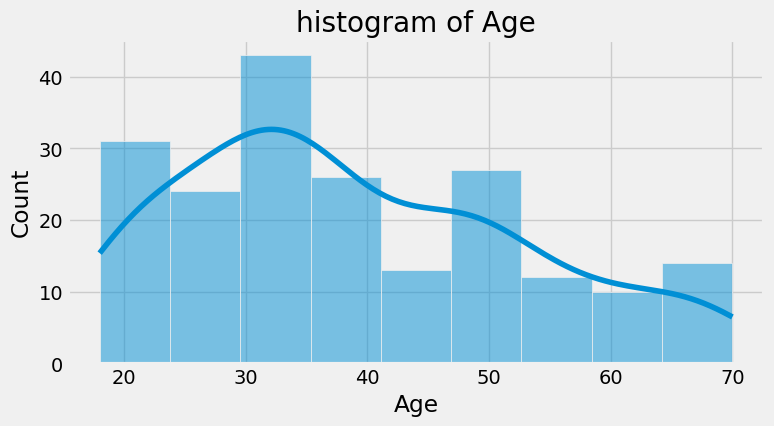

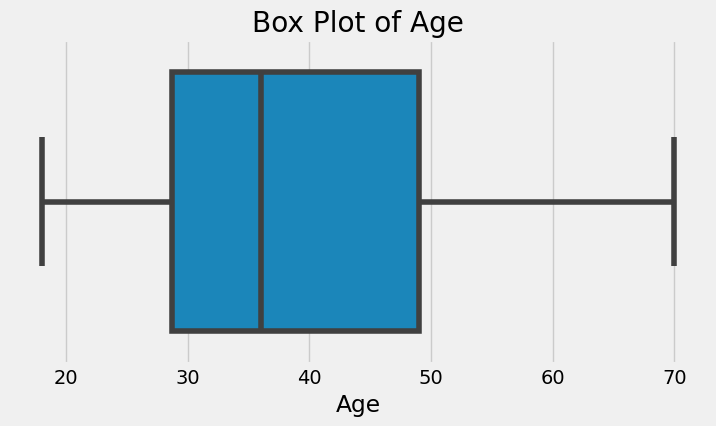



--- Analysis for Annual Income (k$) ---


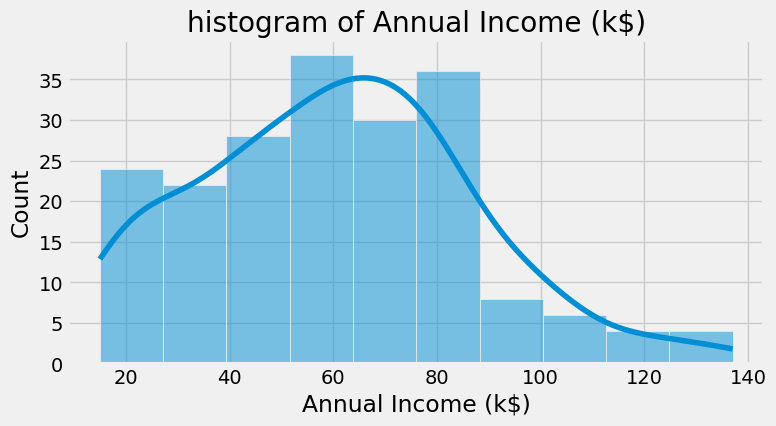

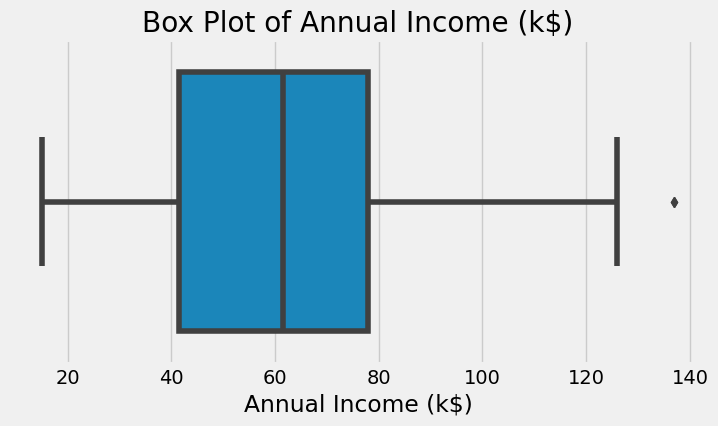



--- Analysis for Spending Score (1-100) ---


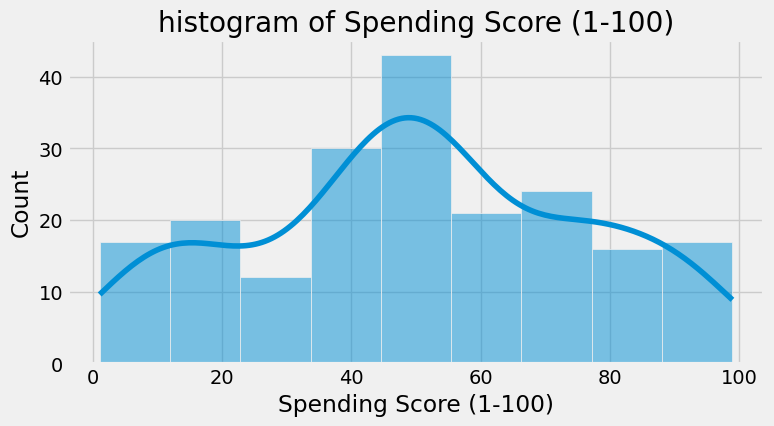

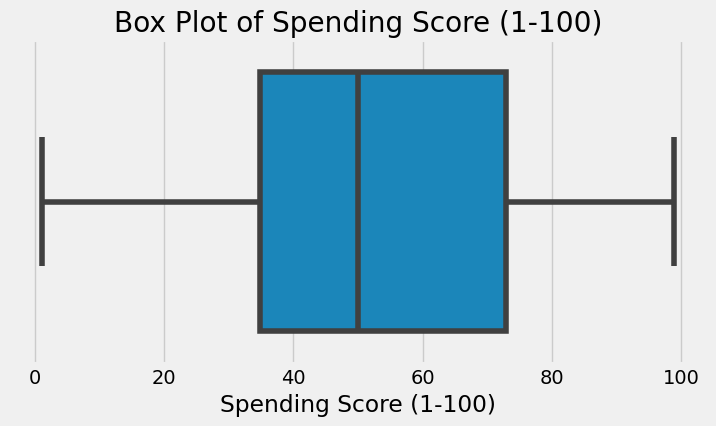

In [13]:
numerical_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for feature in numerical_features:
    print(f"--- Analysis for {feature} ---")
    
    # Histograms
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], kde=True)
    plt.title(f'histogram of {feature}')
    plt.show()
    
    # Box plots for outlier detection
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()
    
    print("\n")

Age distribution analysis
Answer: The age distribution is right-skewed, meaning most individuals are younger, and fewer are older. No significant unusual patterns or outliers are clearly identifiable from the plots.
Explanation:
Distribution Shape (Skewness): Both the histogram and the box plot indicate a right-skewed distribution.
In the histogram, the tail of the data extends further to the right (older ages) than to the left (younger ages), and the peak count is in the younger age (around 30-40 years old).
In the box plot, the median line is slightly left of center within the box, and the right whisker (representing higher ages) is visibly longer than the left whisker (representing lower ages), confirming the right skew.
Central Tendency and Spread:
The majority of the data falls between approximately 30 and 50 years of age (the interquartile range in the box plot).
The overall range is from about 20 to over 70 years old.
Unusual Patterns/Outliers: No data points are plotted individually outside the whiskers of the box plot, which suggests there are no extreme outliers in this dataset. The distribution, while skewed, appears to be a common pattern found in real-world data like human lifespans, where more people die at older ages than younger ages.

The annual income distribution is right-skewed and features a high outlier as the most unusual pattern.
The distribution is unimodal (single peak) and right-skewed. The bulk of the data is concentrated on the left side of the histogram and box plot, with a long tail extending to the right.
Center: The median income (the vertical line inside the box plot's box) appears to be around \$65k.
Spread: Incomes range from approximately \$20k to over \$140k. The middle 50% of incomes (the interquartile range, represented by the box in the box plot) falls roughly between \$45k and \$80k.
Unusual Pattern: Outlier
The most notable unusual pattern is the presence of an outlier in the box plot.
This single data point, represented by the black diamond symbol, is located at an annual income of approximately \$140k, far exceeding the upper whisker of the box plot. This indicates an income value significantly higher than the vast majority of other incomes in the dataset.

The distribution for the spending score is approximately symmetrical and bell-shaped, with no unusual patterns or outliers.
The distribution of the Spending Score (1-100) can be analyzed using both the histogram and the box plot provided: 
Shape: The histogram shows a concentration of data in the center, with frequencies tapering off towards the lower and upper ends, following a rough bell curve shape. The distribution is approximately symmetrical, meaning it is neither strongly skewed to the left nor the right.
Center: The peak of the histogram and the median line in the box plot are both located around the 50-60 mark, indicating the central tendency of the scores.
Spread: The scores range from 0 to 100.
Unusual Patterns: The box plot does not display any individual data points outside of the whiskers, which means there are no significant outliers in the dataset. The overall pattern is consistent with a relatively normal distribution

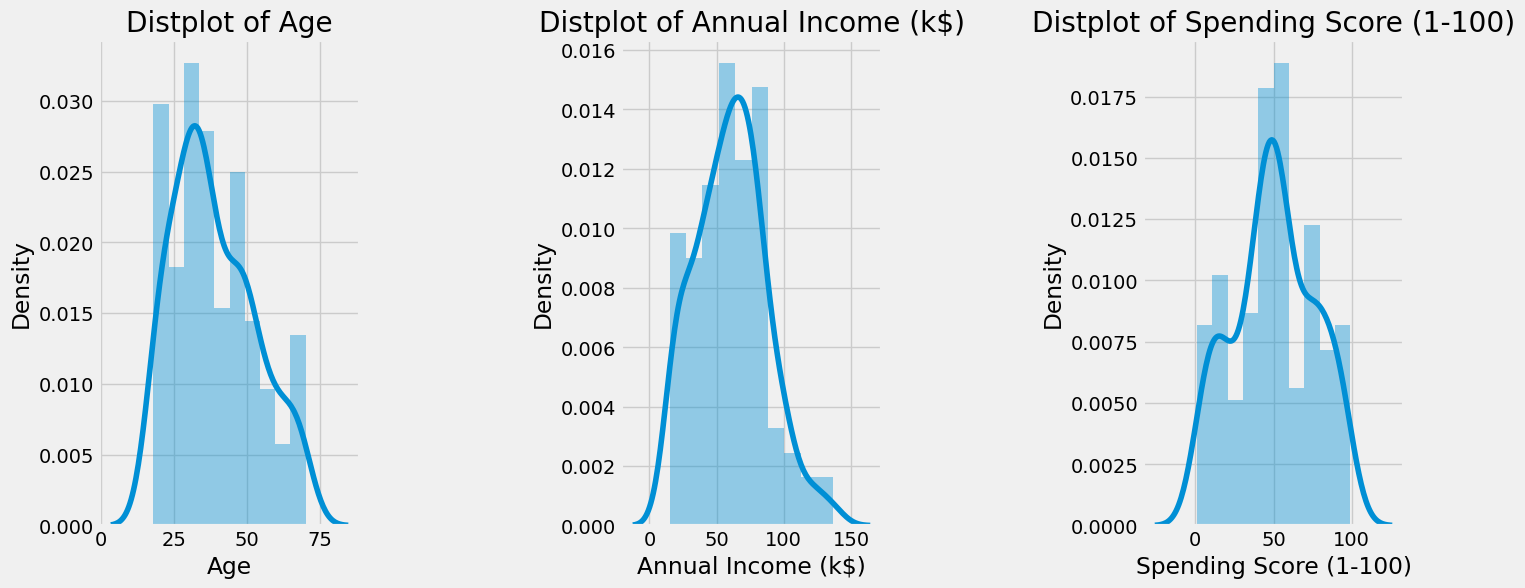

In [14]:
plt.figure(1 , figsize = (15 , 6))
n = 0 
for x in ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1 , 3 , n)
    plt.subplots_adjust(hspace =1, wspace = 1)
    sns.distplot(df[x] , bins = 10)
    plt.title('Distplot of {}'.format(x))
plt.show()

--- value count(for gender) ---


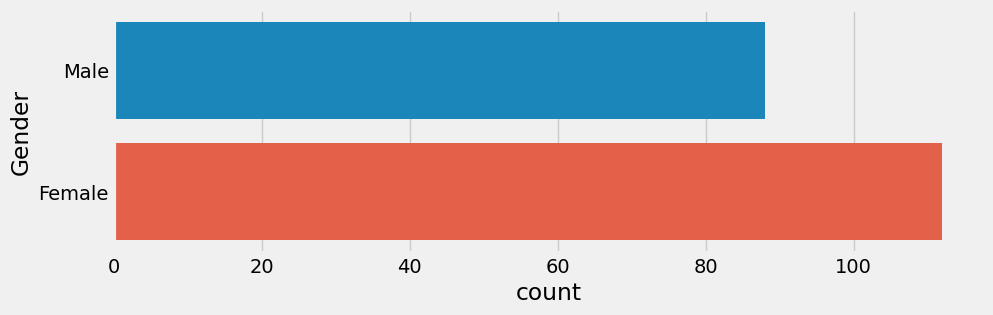

In [15]:
print(f"--- value count(for gender) ---")
plt.figure(1 , figsize = (10 , 3))
sns.countplot(y = 'Gender' , data = df)
plt.show()


# Feature Relationship(Pairwise Analysis) 

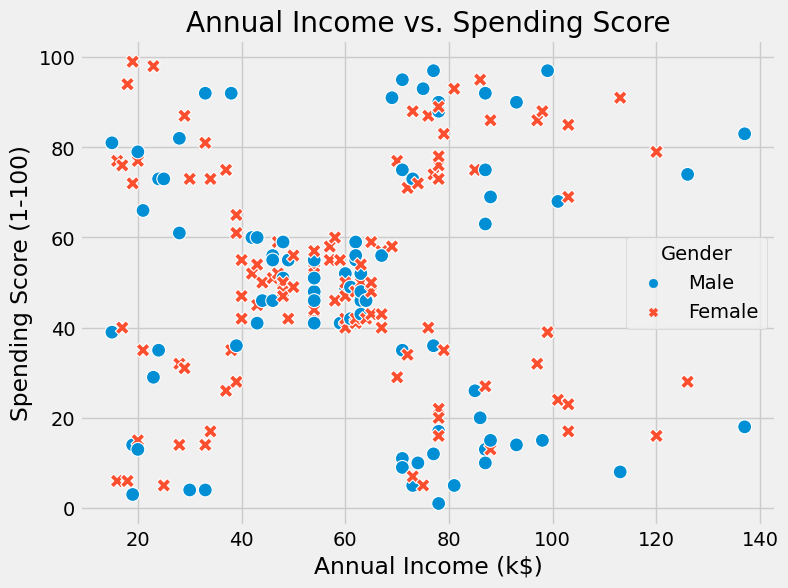

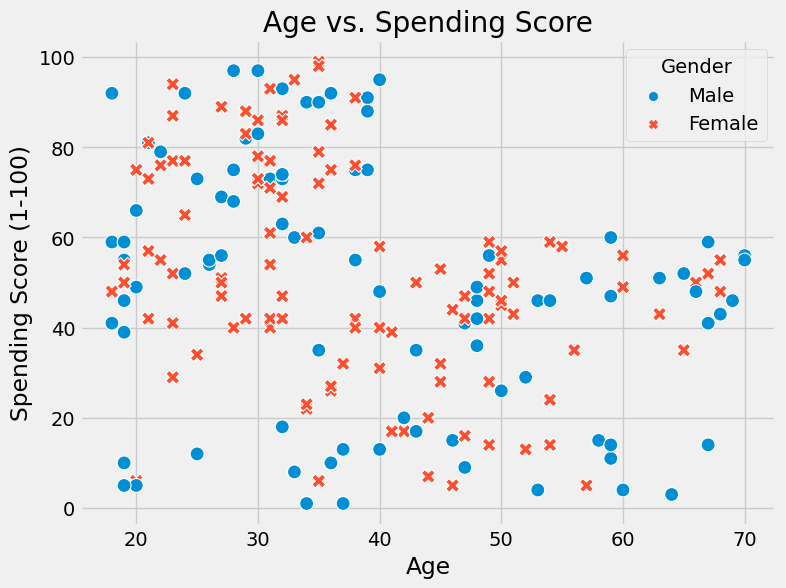

In [16]:
# Create scatter plot for Annual Income vs. Spending Score
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, hue='Gender', style='Gender', s=100)
plt.title('Annual Income vs. Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

# Create scatter plot for Age vs. Spending Score
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=df, hue='Gender', style='Gender', s=100)
plt.title('Age vs. Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show()

# Answer: 
There are several clusters and correlations apparent in the "Annual Income vs. Spending Score" scatter plot. 
Cluster 1 (Low Income, High Spending Score): A distinct group of customers with annual incomes around \$20k to \$40k have high spending scores (70 to 100).
Cluster 2 (Mid Income, Mid Spending Score): A large, dense cluster of customers with incomes around \$40k to \$60k have spending scores in the middle range (40 to 60).
Cluster 3 (High Income, Low Spending Score): A group of customers with higher incomes (around \$80k to \$120k) have low spending scores (10 to 40).
No strong overall correlation: There is no single strong positive or negative linear correlation across the entire dataset; instead, the data forms these distinct clusters, suggesting different customer segments.
Gender distribution: Both male (blue circles) and female (orange crosses) customers are present in all the observed clusters.




# Answer:
There are several clusters of data points, and no clear linear correlation between age and spending score for the overall population.
The clusters can be visually identified in the scatter plot:
Cluster 1 (Top Right): High spending score (around 70-90) and middle age (around 30-40 years old).
Cluster 2 (Top Left): High spending score (around 70-90) and young age (around 20-30 years old).
Cluster 3 (Middle): Average spending score (around 40-60) and a wide range of ages (20-70 years old).
Cluster 4 (Bottom Right): Low spending score (around 0-30) and middle age (around 40-60 years old).
Cluster 5 (Bottom Left): Low spending score (around 0-30) and young age (around 20-35 years old).
There is no strong positive or negative linear correlation across all data points. The gender variable (indicated by color/shape) appears somewhat evenly distributed within most clusters, although the top-left and top-right clusters seem to have a higher proportion of female individuals (orange 'x').

# **Impact of Categorical Features(Gender)**

In [17]:
grouped_stats = df.groupby('Gender')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("Grouped Statistics (Mean):")
print(grouped_stats)

Grouped Statistics (Mean):
              Age  Annual Income (k$)  Spending Score (1-100)
Gender                                                       
Female  38.098214           59.250000               51.526786
Male    39.806818           62.227273               48.511364


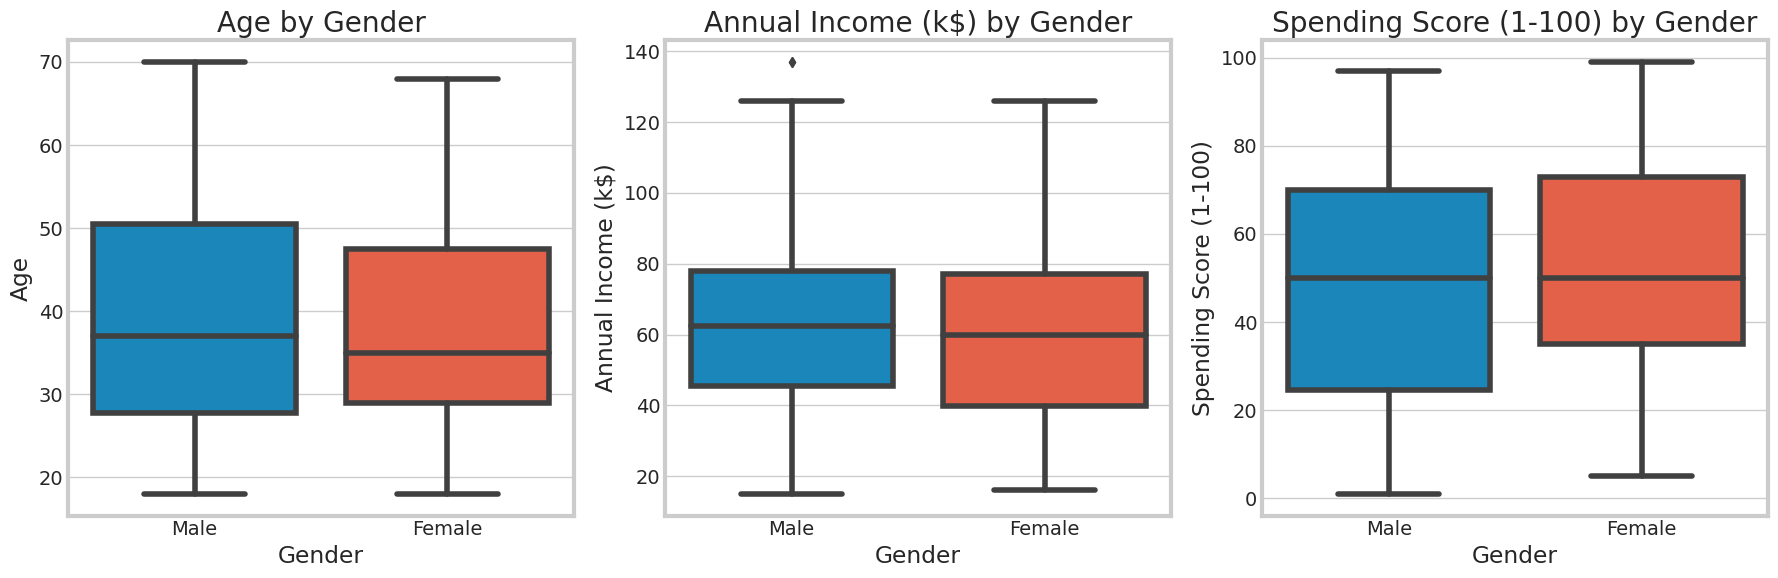

In [18]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='Gender', y='Age', data=df, ax=axes[0])
axes[0].set_title('Age by Gender')

sns.boxplot(x='Gender', y='Annual Income (k$)', data=df, ax=axes[1])
axes[1].set_title('Annual Income (k$) by Gender')

sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df, ax=axes[2])
axes[2].set_title('Spending Score (1-100) by Gender')

plt.tight_layout()
plt.show()

# Answer:
Male and female genders show similar distributions across all three numerical features (Age, Annual Income, and Spending Score), with minimal differences in median values and overall ranges. 
The box plots provide a visual comparison of the distribution for each feature: 
Age: Both genders have similar median ages (around 35-40). The male age range (whiskers) is slightly wider, extending to a younger minimum age.
Annual Income: The median income is nearly identical for both genders, roughly \$60k-\$65k. The overall spread and interquartile ranges are very similar, indicating no significant income disparity between the groups shown. 
Spending Score (1-100): The median spending scores are also very similar for males and females, around 50. The distributions are largely overlapping, suggesting comparable spending habits between the two groups.

# **# Hypothesis Testing(Related to customer Characterstics)**

In [19]:
import scipy.stats as stats

In [20]:
from scipy.stats import f_oneway


In [21]:
age_groups = [df[df['Age'] == age]['Spending Score (1-100)'] for age in df['Age'].unique()]
# Perform one-way ANOVA test
# The null hypothesis is that the average spending score is the same across all age groups.
f_statistic, p_value = stats.f_oneway(*age_groups)
print("Customer Data DataFrame:")
print(df)
print("\nANOVA F-statistic:", f_statistic)
print("ANOVA P-value:", p_value)

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nResult: Reject the null hypothesis (p-value {p_value:.4f} < {alpha}). There is a significant difference in average spending scores between age groups.")
else:
    print(f"\nResult: Fail to reject the null hypothesis (p-value {p_value:.4f} > {alpha}). There is no significant difference in average spending scores between age groups.")

Customer Data DataFrame:
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]

ANOVA F-statistic: 2.4302352079488156
ANOVA P-value: 1.9564351575542006e-0

In [22]:
from scipy.stats import pearsonr

In [23]:
income = df['Annual Income (k$)']
score = df['Spending Score (1-100)']
corr_coeff, p_value = pearsonr(income, score)
print(f"Hypothesis 2 Pearson Correlation Coefficient: {corr_coeff}")
print(f"Hypothesis 2 P-value: {p_value}")
# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nResult: Reject the null hypothesis (p-value {p_value:.4f} < {alpha}). There is a significant difference in annual income and spending score.")
else:
    print(f"\nResult: Fail to reject the null hypothesis (p-value {p_value:.4f} > {alpha}). There is no significant difference in annual income and spending score.")

Hypothesis 2 Pearson Correlation Coefficient: 0.009902848094037624
Hypothesis 2 P-value: 0.8893134370273997

Result: Fail to reject the null hypothesis (p-value 0.8893 > 0.05). There is no significant difference in annual income and spending score.


In [24]:
from scipy.stats import ttest_ind

In [25]:
male_income = df[df['Gender'] == 'Male']['Annual Income (k$)']
female_income = df[df['Gender'] == 'Female']['Annual Income (k$)']
t_statistic, p_value = ttest_ind(male_income, female_income, equal_var=False)
print(f"Hypothesis 3 T-statistic: {t_statistic}")
print(f"Hypothesis 3 P-value: {p_value}")
# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nResult: Reject the null hypothesis (p-value {p_value:.4f} < {alpha}). There is a significant difference in annual income distribution between males and females.")
else:
    print(f"\nResult: Fail to reject the null hypothesis (p-value {p_value:.4f} > {alpha}). There is no significant difference in annual income distribution between males and females.")

Hypothesis 3 T-statistic: 0.7927442280257677
Hypothesis 3 P-value: 0.42894304774991476

Result: Fail to reject the null hypothesis (p-value 0.4289 > 0.05). There is no significant difference in annual income distribution between males and females.


# K-Means and Hierarchical Clustering

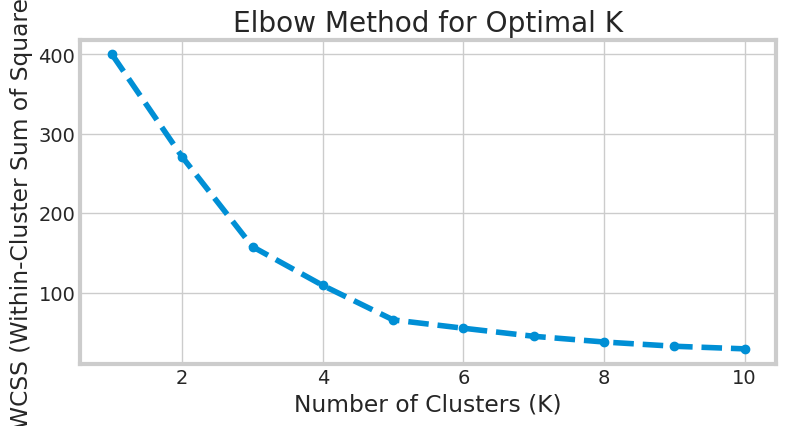

WCSS values for different K:
K = 1: WCSS = 400.00
K = 2: WCSS = 270.70
K = 3: WCSS = 157.70
K = 4: WCSS = 108.92
K = 5: WCSS = 65.57
K = 6: WCSS = 55.06
K = 7: WCSS = 44.91
K = 8: WCSS = 37.74
K = 9: WCSS = 32.38
K = 10: WCSS = 29.09

Observe the plot and identify the 'elbow' point to determine the optimal K.


In [26]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
# 1.Select features for clustering: Annual Income and Spending Score
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Determine Optimal K using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.show()

# Interpret the Elbow Plot
# Look for the "elbow" point where the decrease in WCSS starts to slow down significantly.
# The K value at this point is considered the optimal number of clusters.
print("WCSS values for different K:")
for k_val, wcss_val in zip(range(1, 11), wcss):
    print(f"K = {k_val}: WCSS = {wcss_val:.2f}")

print("\nObserve the plot and identify the 'elbow' point to determine the optimal K.")


Cluster Means:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 88.200000               17.114286
2                 26.304348               20.913043
3                 25.727273               79.363636
4                 86.538462               82.128205

Silhouette Score: 0.55


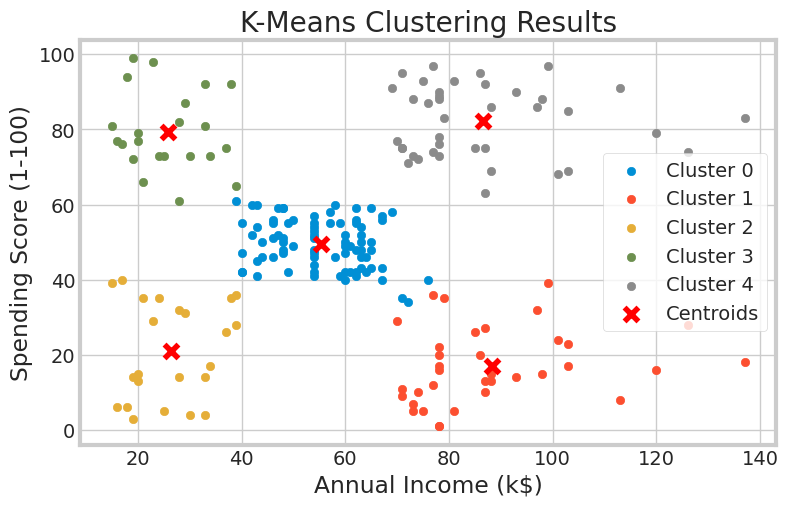

In [27]:
# 3. Apply K-Means with chosen K ( K=5 )
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 4. Analyze Clusters: Mean values of features for each cluster
cluster_means = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("Cluster Means:")
print(cluster_means)

# 4. Evaluate Clusters: Calculate Silhouette Score
score = silhouette_score(X_scaled, df['Cluster'])
print(f"\nSilhouette Score: {score:.2f}")

# 4. Visualize Clusters 
plt.figure(figsize=(8, 5))
for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
                label=f'Cluster {cluster_id}')
plt.scatter(scaler.inverse_transform(kmeans_final.cluster_centers_)[:, 0], 
            scaler.inverse_transform(kmeans_final.cluster_centers_)[:, 1], 
            s=100, c='red', marker='x', label='Centroids')
plt.title('K-Means Clustering Results')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

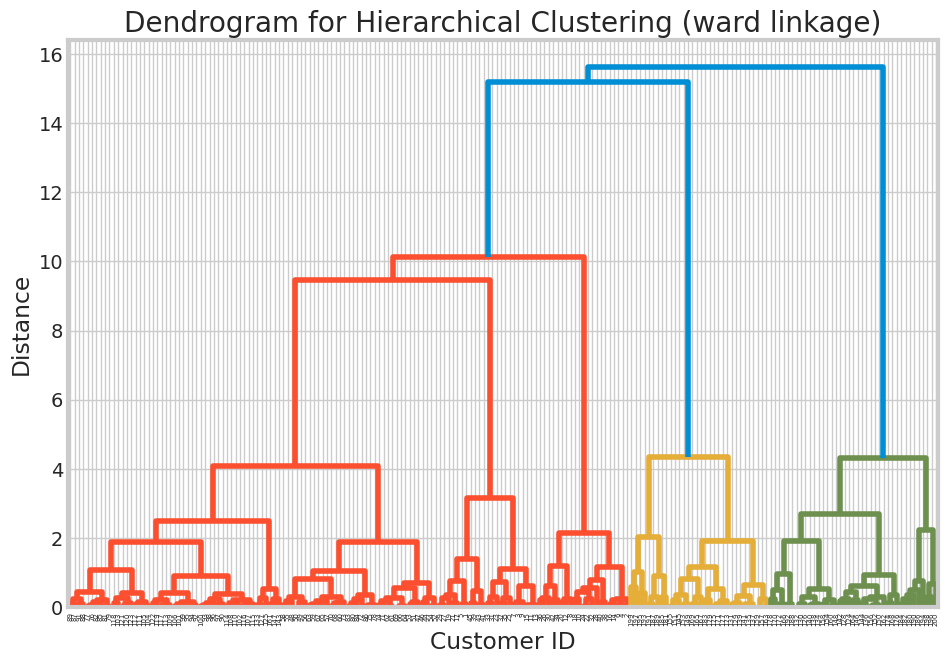

In [28]:
from scipy.cluster.hierarchy import dendrogram, linkage, ward, complete, average
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
# Selecting the features for clustering (Annual Income and Spending Score)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Feature scaling to improve clustering results, especially with different scales
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply Hierarchical Clustering and Visualize Dendrogram
# Using 'ward' linkage 
linkage_method = 'ward'
linked = linkage(X_scaled, method=linkage_method)

plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', labels=df['CustomerID'].values, distance_sort='descending', show_leaf_counts=True)
plt.title(f'Dendrogram for Hierarchical Clustering ({linkage_method} linkage)')
plt.xlabel('Customer ID')
plt.ylabel('Distance')
plt.show()



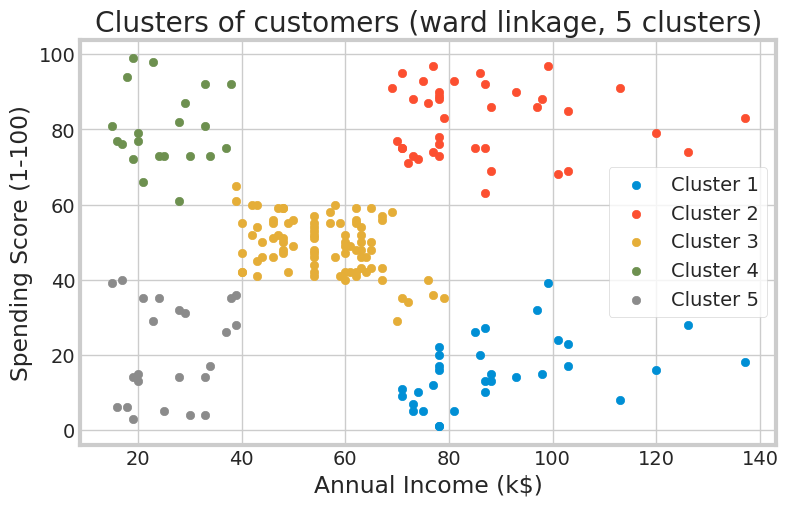

The Silhouette Score for 5 clusters using ward linkage is: 0.5538

Cluster characteristics (mean values):
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 89.406250               15.593750
1                 86.538462               82.128205
2                 55.811765               49.129412
3                 25.095238               80.047619
4                 26.304348               20.913043


In [29]:
# Based on the dendrogram, a suitable number of clusters can be determined 
n_clusters = 5

# 3. Analyze and Visualize Clusters
# Apply Agglomerative Clustering with the chosen number of clusters
hc = AgglomerativeClustering(n_clusters=n_clusters, affinity='euclidean', linkage=linkage_method)
df['Cluster'] = hc.fit_predict(X_scaled)

# Visualize Clusters
plt.figure(figsize=(8, 5))
for cluster_id in range(n_clusters):
    plt.scatter(df[df['Cluster'] == cluster_id]['Annual Income (k$)'],
                df[df['Cluster'] == cluster_id]['Spending Score (1-100)'],
                label=f'Cluster {cluster_id + 1}')
plt.title(f'Clusters of customers ({linkage_method} linkage, {n_clusters} clusters)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

# 4. Evaluate Clusters (Calculate Silhouette Score)
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"The Silhouette Score for {n_clusters} clusters using {linkage_method} linkage is: {silhouette_avg:.4f}")

# Display cluster characteristics 
print("\nCluster characteristics (mean values):")
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

# Compare Clustering Results
Answer: K-Means Clustering performed better than Hierarchical Clustering in this comparison.
Explanation
Silhouette Scores: K-Means clustering has a Silhouette Score of 0.55, which is higher than the Hierarchical Clustering score of 0.4926. A higher score indicates better-defined and more separated clusters.
Interpretability: Both methods produce interpretable segments based on the provided mean values for "Annual Income" and "Spending Score".
K-Means clusters show clear differentiation, for example, between high-income/low-spending (Cluster 1) and low-income/high-spending (Cluster 3) groups.
Hierarchical Clustering also shows distinct groups, such as the younger, low-income/high-spending group (Cluster 3) and an older, high-income/low-spending group (Cluster 2).
Conclusion: Based solely on the quantitative metric provided (Silhouette Score), K-Means clustering is the superior method for this dataset.